Silakan upload file 'banana_ekstraksi_fitur.csv'


Saving banana_ekstraksi_fitur.csv to banana_ekstraksi_fitur.csv

5 data pertama:
            R           G           B          H          S           V  \
0  181.367004  182.705688  156.712341  84.277832  72.689392  193.700073   
1  177.270813  182.751709  159.101257  81.952332  71.195007  192.133545   
2  164.891907  166.865479  140.337463  81.709656  82.528503  179.349304   
3  142.560730  145.648071  131.084595  73.537842  76.091248  159.630554   
4  170.319885  173.055420  136.589661  76.775330  88.372498  181.643066   

     Texture label  
0  52.137135  ripe  
1  54.499265  ripe  
2  48.272717  ripe  
3  69.658607  ripe  
4  57.839709  ripe  

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1123 entries, 0 to 1122
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   R        1123 non-null   float64
 1   G        1123 non-null   float64
 2   B        1123 non-null   float64
 3   H        1123 non-null   f

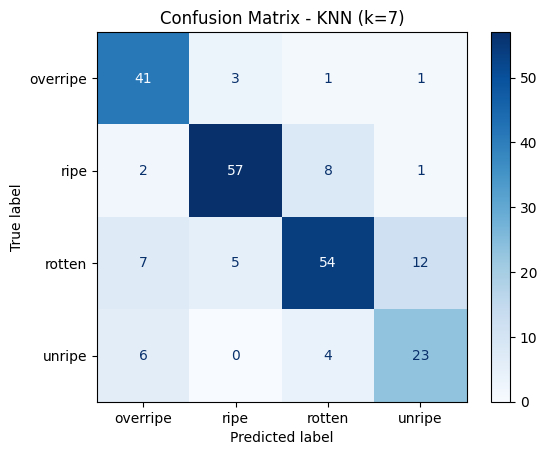

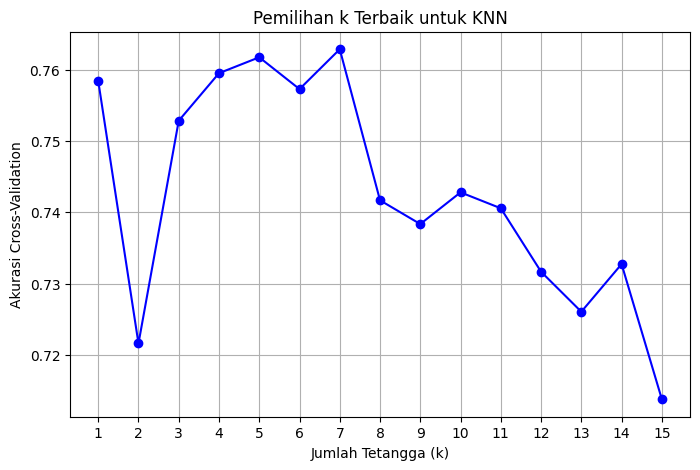


Contoh prediksi:
Data ke-0 -> Prediksi: overripe, Aktual: overripe

Model dan scaler telah disimpan.


In [6]:
# 1. Instalasi & Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from google.colab import files
print("Silakan upload file 'banana_ekstraksi_fitur.csv'")
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("\n5 data pertama:")
print(df.head())

print("\nInfo dataset:")
print(df.info())

print("\nDistribusi label:")
print(df['label'].value_counts())

# 2. Preprocessing
X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split data : train (80%) dan test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nUkuran data training : {X_train.shape}")
print(f"Ukuran data testing  : {X_test.shape}")

# 4. Membangun model KNN dengan hyperparameter tuning
param_grid = {'n_neighbors': range(1, 16)}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"\nNilai k terbaik: {grid_search.best_params_['n_neighbors']}")
print(f"Akurasi CV terbaik: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_

# 5. Evaluasi pada data testing
y_pred = best_knn.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"\nAkurasi pada data testing : {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - KNN (k={best_knn.n_neighbors})')
plt.show()

# 6. Visualisasi hasil (opsional)
k_values = range(1, 16)
cv_scores = grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Jumlah Tetangga (k)')
plt.ylabel('Akurasi Cross-Validation')
plt.title('Pemilihan k Terbaik untuk KNN')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# 7. Contoh prediksi untuk satu data baru (opsional)
sample = X_test[0].reshape(1, -1)
pred_label = best_knn.predict(sample)[0]
true_label = y_test.iloc[0]
print(f"\nContoh prediksi:")
print(f"Data ke-0 -> Prediksi: {pred_label}, Aktual: {true_label}")

# 8. Simpan model (opsional)
import joblib
joblib.dump(best_knn, 'knn_banana_model.pkl')
joblib.dump(scaler, 'scaler_banana.pkl')
print("\nModel dan scaler telah disimpan.")